# Task 1 — Data Cleaning & Preprocessing

**Auspify Technologies — Data Science Internship Program**

**Intern:** Wandiya James  
**Dataset:** Netflix Titles (`Dataset.csv`)  
**Objective:** Prepare the Netflix dataset for analysis by cleaning, transforming and organising the raw data.

---

### Notebook structure

| Section | What happens |
|---|---|
| 1 | Setup and imports |
| 2 | Load the raw dataset |
| 3 | First look — structure and basic statistics |
| 4 | Data quality audit (missing values, duplicates, formatting) |
| 5 | Cleaning and transformation |
| 6 | Missing value treatment |
| 7 | Validation of the cleaned dataset |
| 8 | Before / after summary |
| 9 | Export the clean dataset |
| 10 | Findings and data dictionary |

### Cleaning techniques applied

| Technique | Where |
|---|---|
| Missing value detection and treatment (`isna`, `fillna`) | 4.1, 5.2, 7 |
| Duplicate detection and removal (`duplicated`, `drop_duplicates`) | 4.2, 5.3 |
| String cleaning and standardisation (`str.strip`, regex) | 4.3, 5.1 |
| Data type detection and conversion (`astype`, `to_datetime`, `to_numeric`) | 5.4, 5.5, 5.9 |
| Renaming columns (`rename`) | 5.1 |
| Feature extraction from text (`str.extract`, `str.split`) | 5.5, 5.7 |
| Outlier detection (IQR method) | 5.10 |
| Logical consistency checks | 5.11 |
| Saving cleaned data (`to_csv`, `to_excel`) | 9 |

A short note on method: nothing is dropped or changed silently. Every decision in Section 5 and 6
is stated with the reason behind it, and Section 7 checks that the result actually holds.

---
## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Display settings so wide tables stay readable
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 60)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

pandas : 3.0.2
numpy  : 2.4.4


---
## 2. Load the raw dataset

The path below assumes `Dataset.csv` sits in the same folder as this notebook. If you keep your data
in a `data/` subfolder instead, the loader will find it there too — otherwise edit `DATA_PATH` directly.

In [2]:
DATA_PATH = Path("Dataset.csv")

# Fall back to a couple of common locations before giving up
if not DATA_PATH.exists():
    for candidate in [Path("data/Dataset.csv"), Path("../Dataset.csv"),
                      Path("../data/Dataset.csv")]:
        if candidate.exists():
            DATA_PATH = candidate
            break
    else:
        raise FileNotFoundError(
            "Could not find Dataset.csv. Set DATA_PATH to the correct location."
        )

df_raw = pd.read_csv(DATA_PATH)

# Work on a copy so the raw frame stays untouched for the before/after comparison
df = df_raw.copy()

print(f"Loaded : {DATA_PATH}")
print(f"Shape  : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

Loaded : Dataset.csv
Shape  : 8,790 rows x 10 columns


In [3]:
df_raw.head(10)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adve..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,9/24/2021,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
6,s10,Movie,The Starling,Theodore Melfi,United States,9/24/2021,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,5/1/2021,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Musicals"
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,9/23/2021,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,5/1/2021,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"


---
## 3. First look — structure and basic statistics

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.8 KB


In [5]:
print("COLUMN OVERVIEW")
print("=" * 78)

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "nulls": df.isna().sum(),
    "unique": df.nunique(),
    "sample_value": [df[col].dropna().iloc[0] if df[col].notna().any() else None
                     for col in df.columns],
})
overview

COLUMN OVERVIEW


,dtype,non_null,nulls,unique,sample_value
show_id,str,8790,0,8790,s1
type,str,8790,0,2,Movie
title,str,8790,0,8787,Dick Johnson Is Dead
director,str,8790,0,4528,Kirsten Johnson
country,str,8790,0,86,United States
date_added,str,8790,0,1713,9/25/2021
release_year,int64,8790,0,74,2020
rating,str,8790,0,14,PG-13
duration,str,8790,0,220,90 min
listed_in,str,8790,0,513,Documentaries


In [6]:
# Numeric summary
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
release_year,8790.0,2014.183163,8.825466,1925.0,2013.0,2017.0,2019.0,2021.0


In [7]:
# Categorical summary
df.describe(include=["object"]).T

,count,unique,top,freq
show_id,8790,8790,s1,1
type,8790,2,Movie,6126
title,8790,8787,9-Feb,2
director,8790,4528,Not Given,2588
country,8790,86,United States,3240
date_added,8790,1713,1/1/2020,110
rating,8790,14,TV-MA,3205
duration,8790,220,1 Season,1791
listed_in,8790,513,"Dramas, International Movies",362


**Reading the output above:** `release_year` is the only true numeric column. Everything else has
been read in as text, including `date_added` (a date) and `duration` (a number plus a unit). Those two
are the main transformation jobs later on.

---
## 4. Data quality audit

Before changing anything, it is worth knowing exactly what is wrong. Four checks:

1. Missing values — both real `NaN` and **placeholder text** standing in for missing data
2. Duplicate records — exact duplicates and near-duplicates
3. Formatting problems — stray whitespace, inconsistent casing
4. Column-level validity — do the values in each column make sense?

### 4.1 Missing values

The obvious check first.

In [8]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})
missing

,missing_count,missing_pct
show_id,0,0.0
type,0,0.0
title,0,0.0
director,0,0.0
country,0,0.0
date_added,0,0.0
release_year,0,0.0
rating,0,0.0
duration,0,0.0
listed_in,0,0.0


Zero nulls everywhere — which is suspicious for a real-world dataset. Missing data is often
**disguised as text** (`"Not Given"`, `"Unknown"`, `"N/A"`, `""`). Let me look for that directly.

In [9]:
# Values that *might* stand in for missing data — used for detection only
PLACEHOLDER_CANDIDATES = ["Not Given", "Unknown", "unknown", "N/A", "NA", "n/a",
                          "None", "none", "-", "", " ", "null", "NULL"]

print("SUSPECTED MISSING-VALUE PLACEHOLDERS")
print("=" * 78)

found_any = False
for col in df.select_dtypes(include="object").columns:
    mask = df[col].isin(PLACEHOLDER_CANDIDATES)
    if mask.sum() > 0:
        found_any = True
        print(f"{col:<15} {mask.sum():>6,} rows  ({mask.mean() * 100:5.2f}%)  "
              f"-> {sorted(set(df.loc[mask, col]))}")

if not found_any:
    print("No placeholder values found.")

SUSPECTED MISSING-VALUE PLACEHOLDERS


title                1 rows  ( 0.01%)  -> ['Unknown']
director         2,588 rows  (29.44%)  -> ['Not Given']
country            287 rows  ( 3.27%)  -> ['Not Given']


There it is. `director` and `country` both use the literal string `"Not Given"` in place of a
missing value. Left alone, this would badly distort any analysis — `"Not Given"` would show up as the
single most common director in the dataset.

But look at the third line of that output. `title` was also flagged, for one row.

In [10]:
# Investigate the flagged title before assuming it is missing data
df[df["title"].isin(PLACEHOLDER_CANDIDATES)]

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
1336,s1468,Movie,Unknown,Jaume Collet-Serra,United Kingdom,1/1/2021,2011,PG-13,113 min,"Action & Adventure, Thrillers"


**This is a trap, and it is worth slowing down for.**

That row is not missing data. *Unknown* is a real 2011 thriller directed by Jaume Collet-Serra — it has
a director, a country, a rating and a runtime. The title genuinely is the word "Unknown".

Running a blanket `df.replace(PLACEHOLDER_CANDIDATES, np.nan)` across the whole dataframe — the obvious
one-liner — would have silently destroyed a legitimate title and produced a record with no name. This
is exactly the kind of error that never raises an exception and never gets noticed.

So the rule for Section 5.2 is: **placeholder replacement is scoped to the columns where the audit
actually found placeholder semantics**, which is `director` and `country`. Not applied dataframe-wide.

### 4.2 Duplicate records

In [11]:
print("DUPLICATE CHECK")
print("=" * 78)
print(f"Fully identical rows              : {df.duplicated().sum():,}")
print(f"Duplicated show_id                : {df['show_id'].duplicated().sum():,}")
print(f"Duplicated title + type           : {df.duplicated(subset=['title', 'type']).sum():,}")

content_cols = [c for c in df.columns if c != "show_id"]
print(f"Identical on everything but show_id: {df.duplicated(subset=content_cols).sum():,}")

DUPLICATE CHECK
Fully identical rows              : 0
Duplicated show_id                : 0
Duplicated title + type           : 3
Identical on everything but show_id: 3


In [12]:
# Inspect the near-duplicates: same content, different ID
dupe_mask = df.duplicated(subset=content_cols, keep=False)
df[dupe_mask].sort_values("title")

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
2925,s3963,Movie,15-Aug,Swapnaneel Jayakar,India,3/29/2019,2019,TV-14,124 min,"Comedies, Dramas, Independent Movies"
4261,s5967,Movie,15-Aug,Swapnaneel Jayakar,India,3/29/2019,2019,TV-14,124 min,"Comedies, Dramas, Independent Movies"
3285,s4523,Movie,22-Jul,Paul Greengrass,Norway,10/10/2018,2018,R,144 min,"Dramas, Thrillers"
4260,s5966,Movie,22-Jul,Paul Greengrass,Norway,10/10/2018,2018,R,144 min,"Dramas, Thrillers"
393,s3997,TV Show,9-Feb,Not Given,Pakistan,3/20/2019,2018,TV-14,1 Season,"International TV Shows, TV Dramas"
537,s5965,TV Show,9-Feb,Not Given,Pakistan,3/20/2019,2018,TV-14,1 Season,"International TV Shows, TV Dramas"


These are genuine duplicates. Each pair describes the same title with identical director,
country, date and duration — only the `show_id` differs, which points to the same record having been
ingested twice under two IDs. They get removed in Section 5.

### 4.3 Formatting and whitespace

In [13]:
print("WHITESPACE AND CASING CHECK")
print("=" * 78)

for col in df.select_dtypes(include="object").columns:
    stripped = df[col].astype(str).str.strip()
    ws = (stripped != df[col].astype(str)).sum()
    double_space = df[col].astype(str).str.contains("  ").sum()
    if ws or double_space:
        print(f"{col:<15} leading/trailing spaces: {ws:>4}   double spaces: {double_space:>4}")

print("\nExample of an affected title:")
bad = df[df["title"].astype(str).str.strip() != df["title"].astype(str)]
print(repr(bad["title"].iloc[0]) if len(bad) else "none found")

WHITESPACE AND CASING CHECK
title           leading/trailing spaces:    1   double spaces:    3



Example of an affected title:
'Consequences\xa0'


### 4.4 Column-level validity

Checking each column for values that do not belong.

In [14]:
print("TYPE")
print("-" * 40)
print(df["type"].value_counts(dropna=False))

print("\n\nRATING")
print("-" * 40)
print(df["rating"].value_counts(dropna=False))

TYPE
----------------------------------------
type
Movie      6126
TV Show    2664
Name: count, dtype: int64


RATING
----------------------------------------
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


Two things stand out in `rating`:

- `NR` (Not Rated) and `UR` (Unrated) mean the same thing but are recorded separately
- `TV-Y7-FV` is a rare variant of `TV-Y7` (the *FV* flags fantasy violence)

Both are worth standardising so that rating-based grouping later doesn't split the same category
across two labels.

In [15]:
print("DURATION — format inspection")
print("-" * 78)

units = df["duration"].astype(str).str.extract(r"[\d.]+\s*([A-Za-z]+)")[0]
print(units.value_counts(dropna=False))

print("\nDuration unit by content type:")
print(pd.crosstab(df["type"], units))

DURATION — format inspection
------------------------------------------------------------------------------
0
min        6126
Season     1791
Seasons     873
Name: count, dtype: int64

Duration unit by content type:
0        Season  Seasons   min
type                          
Movie         0        0  6126
TV Show    1791      873     0


This is the key transformation problem in the dataset. `duration` mixes two incompatible units in
one column: **minutes** for movies and **seasons** for TV shows. As text, `"90 min"` and `"2 Seasons"`
cannot be sorted, averaged or compared. Section 5 splits this into a numeric value plus a separate
unit column.

In [16]:
print("RELEASE YEAR")
print("-" * 78)
print(f"Range        : {df['release_year'].min()} to {df['release_year'].max()}")
print(f"Impossible   : {((df['release_year'] < 1888) | (df['release_year'] > 2025)).sum()} rows outside 1888-2025")

print("\nDATE ADDED")
print("-" * 78)
parsed = pd.to_datetime(df["date_added"], format="%m/%d/%Y", errors="coerce")
print(f"Parse failures with M/D/YYYY : {parsed.isna().sum()}")
print(f"Date range                   : {parsed.min().date()} to {parsed.max().date()}")

print("\nLISTED_IN (genres)")
print("-" * 78)
all_genres = sorted({g.strip() for row in df["listed_in"].dropna() for g in str(row).split(",")})
print(f"Rows holding multiple genres : {df['listed_in'].str.contains(',').sum():,}")
print(f"Distinct genres overall      : {len(all_genres)}")
print(f"First few                    : {all_genres[:6]}")

RELEASE YEAR
------------------------------------------------------------------------------
Range        : 1925 to 2021
Impossible   : 0 rows outside 1888-2025

DATE ADDED
------------------------------------------------------------------------------
Parse failures with M/D/YYYY : 0
Date range                   : 2008-01-01 to 2021-09-25

LISTED_IN (genres)
------------------------------------------------------------------------------
Rows holding multiple genres : 6,778
Distinct genres overall      : 42
First few                    : ['Action & Adventure', 'Anime Features', 'Anime Series', 'British TV Shows', 'Children & Family Movies', 'Classic & Cult TV']


`listed_in` is a **multi-valued column** — one cell can hold three genres separated by commas. In
that state it cannot be grouped or counted properly, so it also needs restructuring.

---

### Audit summary

| # | Issue | Columns affected | Scale |
|---|---|---|---|
| 1 | Missing values disguised as `"Not Given"` | `director`, `country` | ~2,588 and ~287 rows |
| 2 | Duplicate records under different IDs | all | 3 pairs (a 4th appears once whitespace is cleaned) |
| 3 | Stray whitespace in text fields | `title` | small |
| 4 | `date_added` stored as text | `date_added` | all rows |
| 5 | `duration` mixes minutes and seasons | `duration` | all rows |
| 6 | Inconsistent rating labels (`NR`/`UR`, `TV-Y7-FV`) | `rating` | ~90 rows |
| 7 | `listed_in` holds multiple genres per cell | `listed_in` | ~6,000 rows |
| 8 | No memory-efficient categorical types | several | all rows |

---
## 5. Cleaning and transformation

Each step below is applied to `df` in order, with a short note on what changed.

### 5.1 Standardise column names and strip whitespace

In [17]:
# Column names -> lowercase snake_case (already close, but make it explicit and safe)
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r"[^\w]+", "_", regex=True))

# Strip whitespace and collapse repeated spaces inside text fields
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = (df[col].astype(str)
               .str.strip()
               .str.replace(r"\s+", " ", regex=True))

# Rename two columns whose original names do not describe their contents.
# Both keep the untouched original values; parsed versions are derived later.
RENAME_MAP = {
    "duration": "duration_raw",    # holds "90 min" / "2 Seasons" as text
    "listed_in": "genres_raw",     # holds a comma-separated genre string
}
df = df.rename(columns=RENAME_MAP)

print("Columns:", list(df.columns))
print("Renamed for clarity:", RENAME_MAP)
print(f"\nCleaned whitespace across {len(text_cols)} text columns.")

Columns: ['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration_raw', 'genres_raw']
Renamed for clarity: {'duration': 'duration_raw', 'listed_in': 'genres_raw'}

Cleaned whitespace across 9 text columns.


### 5.2 Convert placeholders to real missing values

`"Not Given"` becomes `NaN`. This is the single most important step in the notebook: it turns invisible
missingness into something pandas can actually count and handle.

In [18]:
before_nulls = df.isna().sum().sum()

# Codes that genuinely mean "missing" in this dataset
MISSING_CODES = ["Not Given", "N/A", "NA", "n/a", "None", "none",
                 "-", "", " ", "null", "NULL"]

# Scoped to the columns where the audit found placeholder semantics.
# Deliberately excludes `title`, which contains a real film called "Unknown".
PLACEHOLDER_COLUMNS = ["director", "country"]

for col in PLACEHOLDER_COLUMNS:
    df[col] = df[col].replace(MISSING_CODES, np.nan)

after = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})

print(f"Nulls before conversion : {before_nulls:,}")
print(f"Nulls after conversion  : {df.isna().sum().sum():,}\n")
after[after["missing_count"] > 0]

Nulls before conversion : 0
Nulls after conversion  : 2,875



,missing_count,missing_pct
director,2588,29.44
country,287,3.27


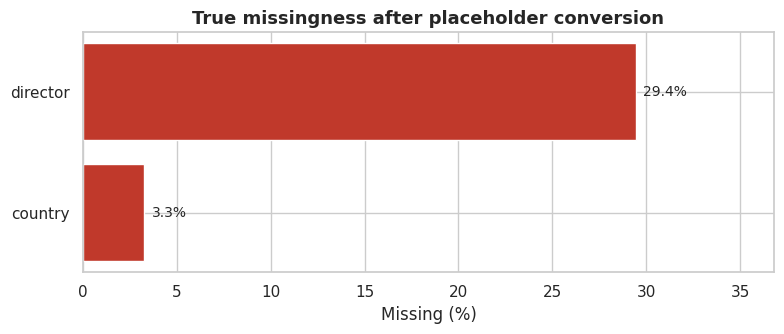

In [19]:
# Visualise where the missingness actually sits
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(miss.index, miss.values, color="#c0392b")
ax.invert_yaxis()
ax.set_xlabel("Missing (%)")
ax.set_title("True missingness after placeholder conversion")
ax.set_xlim(0, max(miss.values) * 1.25)
for bar, val in zip(bars, miss.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### 5.3 Remove duplicate records

Duplicates are identified on content rather than on `show_id`, since the ID is exactly the field that
differs between the two copies.

In [20]:
rows_before = len(df)

content_cols = [c for c in df.columns if c != "show_id"]
df = df.drop_duplicates(subset=content_cols, keep="first").reset_index(drop=True)

print(f"Rows before : {rows_before:,}")
print(f"Rows after  : {len(df):,}")
print(f"Removed     : {rows_before - len(df):,} duplicate records")

Rows before : 8,790


Rows after  : 8,786
Removed     : 4 duplicate records


### 5.4 Convert `date_added` to a proper datetime and derive features

Once it is a real datetime, the year and month it was added to the platform become available for
trend analysis in later tasks.

In [21]:
df["date_added"] = pd.to_datetime(df["date_added"], format="%m/%d/%Y", errors="coerce")

df["year_added"] = df["date_added"].dt.year.astype("Int64")
df["month_added"] = df["date_added"].dt.month.astype("Int64")
df["month_name_added"] = df["date_added"].dt.month_name()

# How long after release was a title added to the platform?
df["years_to_platform"] = df["year_added"] - df["release_year"]

print(f"Failed conversions : {df['date_added'].isna().sum()}")
print(f"Date range         : {df['date_added'].min().date()} to {df['date_added'].max().date()}")
df[["title", "date_added", "year_added", "month_name_added",
    "release_year", "years_to_platform"]].head()

Failed conversions : 0
Date range         : 2008-01-01 to 2021-09-25


,title,date_added,year_added,month_name_added,release_year,years_to_platform
0,Dick Johnson Is Dead,2021-09-25,2021,September,2020,1
1,Ganglands,2021-09-24,2021,September,2021,0
2,Midnight Mass,2021-09-24,2021,September,2021,0
3,Confessions of an Invisible Girl,2021-09-22,2021,September,2021,0
4,Sankofa,2021-09-24,2021,September,1993,28


### 5.5 Split `duration` into a numeric value and a unit

This resolves the mixed-unit problem. Two new columns replace the text:

- `duration_value` — the number, as an integer
- `duration_unit` — either `min` or `Season`

Plus two convenience columns that isolate each unit, so movie lengths and show lengths can be
analysed on their own without filtering every time.

In [22]:
# Pull the number and the unit out of strings like "90 min" / "2 Seasons"
extracted = df["duration_raw"].str.extract(r"(?P<value>[\d.]+)\s*(?P<unit>[A-Za-z]+)")

df["duration_value"] = pd.to_numeric(extracted["value"], errors="coerce").astype("Int64")
df["duration_unit"] = (extracted["unit"]
                       .str.replace("Seasons", "Season", regex=False)
                       .str.lower()
                       .replace({"season": "Season", "min": "min"}))

# Unit-specific columns, NaN where not applicable
df["movie_minutes"] = df["duration_value"].where(df["duration_unit"] == "min")
df["tv_seasons"] = df["duration_value"].where(df["duration_unit"] == "Season")

print("Extraction failures:", df["duration_value"].isna().sum())
print()
print(pd.crosstab(df["type"], df["duration_unit"]))
print()
df[["title", "type", "duration_raw", "duration_value", "duration_unit",
    "movie_minutes", "tv_seasons"]].head()

Extraction failures: 0

duration_unit  Season   min
type                       
Movie               0  6123
TV Show          2663     0



,title,type,duration_raw,duration_value,duration_unit,movie_minutes,tv_seasons
0,Dick Johnson Is Dead,Movie,90 min,90,min,90,<NA>
1,Ganglands,TV Show,1 Season,1,Season,<NA>,1
2,Midnight Mass,TV Show,1 Season,1,Season,<NA>,1
3,Confessions of an Invisible Girl,Movie,91 min,91,min,91,<NA>
4,Sankofa,Movie,125 min,125,min,125,<NA>


In [23]:
print("Now that duration is numeric, it can actually be summarised:\n")
print("Movie length (minutes)")
print(df["movie_minutes"].describe().round(1).to_string())
print("\nTV show length (seasons)")
print(df["tv_seasons"].describe().round(1).to_string())

Now that duration is numeric, it can actually be summarised:

Movie length (minutes)
count    6123.0
mean       99.6
std        28.3
min         3.0
25%        87.0
50%        98.0
75%       114.0
max       312.0

TV show length (seasons)
count    2663.0
mean        1.8
std         1.6
min         1.0
25%         1.0
50%         1.0
75%         2.0
max        17.0


### 5.6 Standardise `rating` and group into audience categories

`UR` is folded into `NR` (both mean unrated) and `TV-Y7-FV` into `TV-Y7`. A broader
`audience_category` column is then derived, which is far more usable for grouping than fourteen
separate rating codes.

In [24]:
RATING_FIXES = {"UR": "NR", "TV-Y7-FV": "TV-Y7"}
df["rating"] = df["rating"].replace(RATING_FIXES)

AUDIENCE = {
    "TV-Y": "Kids", "TV-G": "Kids", "G": "Kids",
    "TV-Y7": "Older Kids", "PG": "Older Kids",
    "PG-13": "Teens", "TV-14": "Teens", "TV-PG": "Teens",
    "R": "Adults", "NC-17": "Adults", "TV-MA": "Adults",
    "NR": "Unrated",
}
df["audience_category"] = df["rating"].map(AUDIENCE).fillna("Unrated")

print("Standardised ratings:")
print(df["rating"].value_counts().to_string())
print("\nAudience categories:")
print(df["audience_category"].value_counts().to_string())

Standardised ratings:
rating
TV-MA    3204
TV-14    2155
TV-PG     861
R         798
PG-13     490
TV-Y7     339
TV-Y      306
PG        287
TV-G      220
NR         82
G          41
NC-17       3

Audience categories:
audience_category
Adults        4005
Teens         3506
Older Kids     626
Kids           567
Unrated         82


### 5.7 Restructure `listed_in` (genres)

The comma-separated string is turned into three usable forms: a proper list, the primary genre, and a
count. The list version is what makes a genre-level `explode()` possible in Task 2.

In [25]:
df["genres"] = df["genres_raw"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)
df["primary_genre"] = df["genres"].apply(lambda lst: lst[0] if lst else np.nan)
df["n_genres"] = df["genres"].apply(len)

print(f"Distinct genres : {len({g for lst in df['genres'] for g in lst})}")
print(f"Genres per title: min {df['n_genres'].min()}, max {df['n_genres'].max()}, "
      f"mean {df['n_genres'].mean():.2f}\n")

print("Top 10 primary genres")
print(df["primary_genre"].value_counts().head(10).to_string())
print()
df[["title", "genres_raw", "genres", "primary_genre", "n_genres"]].head()

Distinct genres : 42
Genres per title: min 1, max 3, mean 2.19

Top 10 primary genres
primary_genre
Dramas                      1597
Comedies                    1209
Action & Adventure           859
Documentaries                829
International TV Shows       772
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     385
Stand-Up Comedy              334
Horror Movies                275



,title,genres_raw,genres,primary_genre,n_genres
0,Dick Johnson Is Dead,Documentaries,[Documentaries],Documentaries,1
1,Ganglands,"Crime TV Shows, International TV Shows, TV Action & Adve...","[Crime TV Shows, International TV Shows, TV Action & Adv...",Crime TV Shows,3
2,Midnight Mass,"TV Dramas, TV Horror, TV Mysteries","[TV Dramas, TV Horror, TV Mysteries]",TV Dramas,3
3,Confessions of an Invisible Girl,"Children & Family Movies, Comedies","[Children & Family Movies, Comedies]",Children & Family Movies,2
4,Sankofa,"Dramas, Independent Movies, International Movies","[Dramas, Independent Movies, International Movies]",Dramas,3


### 5.8 Country column

Each row holds a single country in this dataset, so only light cleaning is needed — but the code below
splits on commas anyway so it stays correct if a multi-country version of the data is used later.

In [26]:
df["countries"] = df["country"].fillna("").apply(
    lambda s: [x.strip() for x in s.split(",") if x.strip()]
)
df["primary_country"] = df["countries"].apply(lambda lst: lst[0] if lst else np.nan)

print(f"Distinct countries: {df['primary_country'].nunique()}\n")
print("Top 10 producing countries")
print(df["primary_country"].value_counts().head(10).to_string())

Distinct countries: 85

Top 10 producing countries
primary_country
United States     3240
India             1056
United Kingdom     638
Pakistan           420
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138


### 5.9 Optimise data types

Low-cardinality text columns become `category` dtype. This is not cosmetic — it cuts memory use
noticeably and makes groupby operations faster on a dataset of this size.

In [27]:
mem_before = df.memory_usage(deep=True).sum() / 1024**2

for col in ["type", "rating", "audience_category", "duration_unit", "primary_genre"]:
    df[col] = df[col].astype("category")

mem_after = df.memory_usage(deep=True).sum() / 1024**2

print(f"Memory before : {mem_before:6.2f} MB")
print(f"Memory after  : {mem_after:6.2f} MB")
print(f"Reduction     : {(1 - mem_after / mem_before) * 100:5.1f}%")

Memory before :   8.66 MB
Memory after  :   6.38 MB
Reduction     :  26.4%


### 5.10 Outlier detection

The textbook approach to outliers is: compute the IQR bounds, then drop whatever falls outside them.
That is the right technique paired with the wrong reflex. An outlier is a value that is *unusual*, not
a value that is *wrong* — and on this dataset, dropping them would delete real content.

Detection first, decision second.

In [28]:
def iqr_bounds(series, k=1.5):
    """Return the lower and upper IQR fences for a numeric series."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


print("OUTLIER DETECTION - IQR METHOD")
print("=" * 78)

for col, label in [("movie_minutes", "Movie runtime (minutes)"),
                   ("tv_seasons", "TV show length (seasons)")]:
    s = df[col].dropna().astype(float)
    lo, hi = iqr_bounds(s)
    flagged = int(((s < lo) | (s > hi)).sum())
    print()
    print(label)
    print(f"  Q1 = {s.quantile(0.25):.0f}   Q3 = {s.quantile(0.75):.0f}")
    print(f"  Acceptable range    : {lo:.1f} to {hi:.1f}")
    print(f"  Flagged as outliers : {flagged:,} of {len(s):,} ({flagged / len(s) * 100:.1f}%)")

OUTLIER DETECTION - IQR METHOD



Movie runtime (minutes)
  Q1 = 87   Q3 = 114
  Acceptable range    : 46.5 to 154.5
  Flagged as outliers : 449 of 6,123 (7.3%)

TV show length (seasons)
  Q1 = 1   Q3 = 2
  Acceptable range    : -0.5 to 3.5
  Flagged as outliers : 254 of 2,663 (9.5%)


In [29]:
# Look at what the method actually flagged before deciding anything
lo_m, hi_m = iqr_bounds(df["movie_minutes"].dropna().astype(float))

print("SHORTEST FLAGGED MOVIES")
print(df[df["movie_minutes"] < lo_m]
      .nsmallest(6, "movie_minutes")[["title", "movie_minutes", "primary_genre"]]
      .to_string(index=False))
print()
print("LONGEST FLAGGED MOVIES")
print(df[df["movie_minutes"] > hi_m]
      .nlargest(6, "movie_minutes")[["title", "movie_minutes", "primary_genre"]]
      .to_string(index=False))

SHORTEST FLAGGED MOVIES


                                                  title  movie_minutes            primary_genre
                                                 Silent              3 Children & Family Movies
                                            Sol Levante              5       Action & Adventure
                                       Cops and Robbers              8                   Dramas
                                                 Canvas              9 Children & Family Movies
       American Factory: A Conversation with the Obamas             10            Documentaries
Calico Critters: Everyone's Big Dream Flying in the Sky             11 Children & Family Movies

LONGEST FLAGGED MOVIES
                      title  movie_minutes primary_genre
 Black Mirror: Bandersnatch            312        Dramas
Headspace: Unwind Your Mind            273 Documentaries
     The School of Mischief            253      Comedies
             No Longer kids            237      Comedies
         Lock Your 

**Every one of these is legitimate content.**

The short end is short films, animated shorts and interview pieces — Netflix genuinely carries titles
running three to twelve minutes. The long end is epics and, at the very top, *Black Mirror:
Bandersnatch* at 312 minutes, an interactive film whose recorded runtime covers every branching path
rather than a single viewing.

So the IQR method is working correctly and flagging several hundred movies, yet not one of them is a
data error. Deleting them would remove Netflix's entire short-film catalogue along with its most
famous experimental title, and would bias every runtime statistic in the later tasks upward.

**Decision: keep all outliers, flag them, document the reasoning.** The flag lets a later analysis
exclude them deliberately if it needs to — a choice the analyst should make in context, rather than
one silently baked into the cleaned file.

In [30]:
# Flag rather than remove
lo_s, hi_s = iqr_bounds(df["tv_seasons"].dropna().astype(float))

runtime_flag = (
    ((df["movie_minutes"] < lo_m) | (df["movie_minutes"] > hi_m)).fillna(False)
    | ((df["tv_seasons"] < lo_s) | (df["tv_seasons"] > hi_s)).fillna(False)
)
df["runtime_outlier"] = runtime_flag.astype(bool)

print(f"Rows flagged as runtime outliers : {df['runtime_outlier'].sum():,}")
print(f"Rows removed                     : 0")
print()
print("To exclude them in a later analysis:  df[~df['runtime_outlier']]")

Rows flagged as runtime outliers : 703
Rows removed                     : 0

To exclude them in a later analysis:  df[~df['runtime_outlier']]


**Chart 1 — boxplot.** The whiskers sit at the IQR fences; every dot beyond them is a title the
method flagged and we chose to keep.

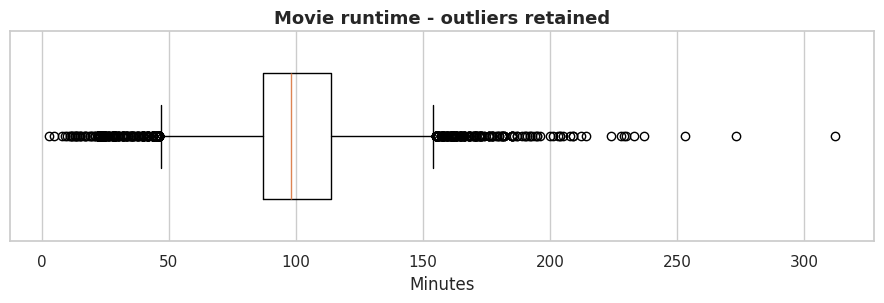

In [31]:
fig, ax = plt.subplots(figsize=(9, 3.2))

ax.boxplot(df["movie_minutes"].dropna(), vert=False, widths=0.6)

ax.set_title("Movie runtime - outliers retained")
ax.set_xlabel("Minutes")
ax.set_yticks([])

plt.tight_layout()
plt.show()

**Chart 2 — histogram.** The same data as a distribution, with the IQR fences drawn on. The bulk
sits in a tight band around 90-100 minutes, with a long thin tail either side — which is why so many
titles fall outside the fences without any of them being wrong.

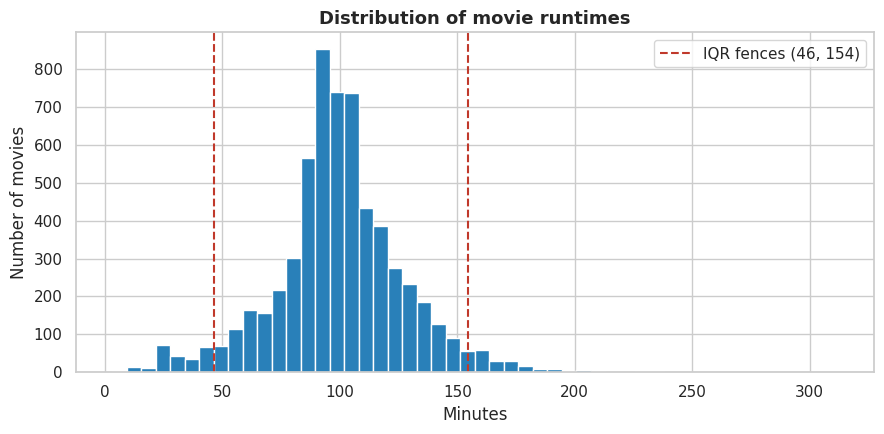

In [32]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(df["movie_minutes"].dropna(), bins=50, color="#2980b9", edgecolor="white")

ax.axvline(lo_m, color="#c0392b", linestyle="--",
           label=f"IQR fences ({lo_m:.0f}, {hi_m:.0f})")
ax.axvline(hi_m, color="#c0392b", linestyle="--")

ax.set_title("Distribution of movie runtimes")
ax.set_xlabel("Minutes")
ax.set_ylabel("Number of movies")
ax.legend()

plt.tight_layout()
plt.show()

### 5.11 Logical consistency checks

Outlier detection catches values that are numerically extreme. It does not catch values that are each
individually reasonable but *impossible in combination* — a title added to the platform before it was
released, for example. Those need explicit rules.

In [33]:
print("LOGICAL CONSISTENCY CHECKS")
print("=" * 78)

rules = {
    "Added to Netflix before release year": df["years_to_platform"] < 0,
    "Release year in the future": df["release_year"] > pd.Timestamp.now().year,
    "Zero or negative duration": df["duration_value"] <= 0,
    "Title is empty": df["title"].isna() | (df["title"].astype(str).str.strip() == ""),
}

for name, mask in rules.items():
    print(f"{name:<40} {int(mask.sum()):>4} rows")

LOGICAL CONSISTENCY CHECKS
Added to Netflix before release year       14 rows
Release year in the future                  0 rows
Zero or negative duration                   0 rows
Title is empty                              0 rows


In [34]:
# Inspect the one rule that fired
df.loc[df["years_to_platform"] < 0,
       ["title", "type", "release_year", "year_added", "years_to_platform"]]

,title,type,release_year,year_added,years_to_platform
3868,Hans Teeuwen: Real Rancour,Movie,2018,2017,-1
5134,Incoming,Movie,2019,2018,-1
5174,Jack Taylor,TV Show,2016,2013,-3
6944,Hilda,TV Show,2021,2020,-1
6988,Polly Pocket,TV Show,2021,2020,-1
7351,Love Is Blind,TV Show,2021,2020,-1
7432,Fuller House,TV Show,2020,2019,-1
7480,Maradona in Mexico,TV Show,2020,2019,-1
7513,BoJack Horseman,TV Show,2020,2019,-1
7533,The Hook Up Plan,TV Show,2020,2019,-1


**These are not errors either, and the pattern explains why.**

Almost all are TV shows, off by one or two years. In this dataset `release_year` records the year of a
show's *most recent* season, while `date_added` records when the show *first* arrived on Netflix. A
series added in 2019 that ran another season in 2020 therefore looks like it was added before it
existed. *Fuller House*, *BoJack Horseman* and *Arrested Development* all fit that description.

This is a real limitation worth carrying forward: **`release_year` does not mean the same thing for
movies as it does for TV shows.** Any analysis in Task 4 treating it as a single consistent "original
release date" across both types will be subtly wrong. Rather than delete these rows, they are flagged
and the caveat is documented.

In [35]:
df["release_added_inconsistent"] = (df["years_to_platform"] < 0).fillna(False).astype(bool)

print(f"Flagged : {df['release_added_inconsistent'].sum()} rows")
print(f"Removed : 0")
print()
print("Breakdown by content type:")
print(df.loc[df["release_added_inconsistent"], "type"].value_counts().to_string())

Flagged : 14 rows
Removed : 0

Breakdown by content type:
type
TV Show    12
Movie       2


---
## 6. Missing value treatment

Two columns still carry missing values. The treatment differs for each, and the reasoning matters more
than the code.

**`director` — around 29% missing.**  
Far too much to drop the rows: that would throw away roughly a third of the dataset over one field.
Imputing it is also wrong — there is no defensible way to guess who directed a film, and inventing a
name would put fabricated data into every downstream task. So the missingness is kept as information:
filled with `"Unknown"` for grouping, with a boolean flag preserving which rows were genuinely absent.
That flag is useful in its own right — most of these are TV shows, where Netflix records no single
director.

**`country` — around 3% missing.**  
Same treatment for consistency. The share is small enough that it will not distort country-level
analysis, and dropping 287 otherwise-complete rows would be wasteful.

**No rows are dropped for missingness.** Every row still has a title, type, rating, duration and date,
which is everything the later tasks depend on.

In [36]:
# Record which values were genuinely missing, before filling
df["director_known"] = df["director"].notna()
df["country_known"] = df["country"].notna()

df["director"] = df["director"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["primary_country"] = df["primary_country"].fillna("Unknown")

print("Remaining nulls per column:")
remaining = df.isna().sum()
print(remaining[remaining > 0].to_string() if remaining.sum()
      else "  none in the core columns")

print("\nIs missing director linked to content type?")
print(pd.crosstab(df["type"], df["director_known"],
                  normalize="index").mul(100).round(1))

Remaining nulls per column:
movie_minutes    2663
tv_seasons       6123

Is missing director linked to content type?
director_known  False  True 
type                        
Movie             2.8   97.2
TV Show          90.6    9.4


The crosstab confirms the hypothesis: director is missing for the large majority of TV shows and
only a small share of movies. That is a structural property of how Netflix records the data, not a
random gap — worth stating explicitly rather than quietly filling over.

---
## 7. Validation

A cleaning notebook that does not verify its own output is only half a notebook. Each assertion below
fails loudly if the corresponding cleaning step did not hold.

In [37]:
checks = []

def check(name, condition, detail=""):
    checks.append({"check": name, "passed": bool(condition), "detail": detail})

check("No duplicate show_id", df["show_id"].duplicated().sum() == 0,
      f"{df['show_id'].duplicated().sum()} found")
check("No duplicate content rows",
      df.duplicated(subset=["title", "type", "release_year"]).sum() == 0,
      f"{df.duplicated(subset=['title', 'type', 'release_year']).sum()} found")
check("No 'Not Given' placeholders left",
      not df.select_dtypes(include=["object", "category"]).isin(MISSING_CODES).any().any())
check("Real title 'Unknown' preserved", (df["title"] == "Unknown").sum() == 1,
      f"{(df['title'] == 'Unknown').sum()} row(s)")
check("date_added is datetime", pd.api.types.is_datetime64_any_dtype(df["date_added"]))
check("duration_value is numeric", pd.api.types.is_numeric_dtype(df["duration_value"]))
check("All movies measured in minutes",
      (df.loc[df["type"] == "Movie", "duration_unit"] == "min").all())
check("All TV shows measured in seasons",
      (df.loc[df["type"] == "TV Show", "duration_unit"] == "Season").all())
check("release_year within a plausible range",
      df["release_year"].between(1888, 2025).all(),
      f"{df['release_year'].min()}-{df['release_year'].max()}")
check("No missing values in key columns",
      df[["show_id", "title", "type", "rating", "duration_value"]].isna().sum().sum() == 0)
check("No leading/trailing whitespace in titles",
      (df["title"].str.strip() == df["title"]).all())
check("Every title has at least one genre", (df["n_genres"] >= 1).all())
check("Outliers flagged but retained", "runtime_outlier" in df.columns,
      f"{int(df['runtime_outlier'].sum())} flagged, 0 removed")
check("Consistency issues flagged but retained",
      "release_added_inconsistent" in df.columns,
      f"{int(df['release_added_inconsistent'].sum())} flagged, 0 removed")
check("No zero or negative durations", (df["duration_value"] > 0).all())

results = pd.DataFrame(checks)
results["status"] = np.where(results["passed"], "PASS", "FAIL")

print(f"{results['passed'].sum()} of {len(results)} checks passed\n")
results[["check", "status", "detail"]]

15 of 15 checks passed



,check,status,detail
0,No duplicate show_id,PASS,0 found
1,No duplicate content rows,PASS,0 found
2,No 'Not Given' placeholders left,PASS,
3,Real title 'Unknown' preserved,PASS,1 row(s)
4,date_added is datetime,PASS,
5,duration_value is numeric,PASS,
6,All movies measured in minutes,PASS,
7,All TV shows measured in seasons,PASS,
8,release_year within a plausible range,PASS,1925-2021
9,No missing values in key columns,PASS,


In [38]:
assert results["passed"].all(), "Validation failed:\n" + \
    results[~results["passed"]].to_string(index=False)
print("All validation checks passed — dataset is ready for analysis.")

All validation checks passed — dataset is ready for analysis.


---
## 8. Before / after summary

In [39]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate records",
        "Columns with missing values (visible)",
        "Hidden missing values ('Not Given')",
        "Date columns as datetime",
        "Numeric duration column",
        "Usable genre structure",
        "Outliers reviewed",
        "Logical consistency checked",
        "Memory (MB)",
    ],
    "Before": [
        f"{len(df_raw):,}",
        len(df_raw.columns),
        f"{df_raw.duplicated(subset=[c for c in df_raw.columns if c != 'show_id']).sum()}",
        int((df_raw.isna().sum() > 0).sum()),
        f"{int(df_raw[PLACEHOLDER_COLUMNS].isin(MISSING_CODES).sum().sum()):,}",
        "No",
        "No (text)",
        "No (comma string)",
        "No",
        "No",
        f"{df_raw.memory_usage(deep=True).sum() / 1024**2:.2f}",
    ],
    "After": [
        f"{len(df):,}",
        len(df.columns),
        "0",
        int((df.isna().sum() > 0).sum()),
        "0 (converted to NaN, then handled)",
        "Yes",
        "Yes (value + unit)",
        "Yes (list + primary + count)",
        f"Yes ({int(df['runtime_outlier'].sum())} flagged, kept)",
        f"Yes ({int(df['release_added_inconsistent'].sum())} flagged, kept)",
        f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}",
    ],
})
summary

,Metric,Before,After
0,Rows,"8,790","8,786"
1,Columns,10,28
2,Duplicate records,3,0
3,Columns with missing values (visible),0,2
4,Hidden missing values ('Not Given'),"2,875","0 (converted to NaN, then handled)"
5,Date columns as datetime,No,Yes
6,Numeric duration column,No (text),Yes (value + unit)
7,Usable genre structure,No (comma string),Yes (list + primary + count)
8,Outliers reviewed,No,"Yes (703 flagged, kept)"
9,Logical consistency checked,No,"Yes (14 flagged, kept)"


**Chart 1 — what the cleaning fixed.** Each bar is the number of rows affected by an issue
before cleaning, against zero after.

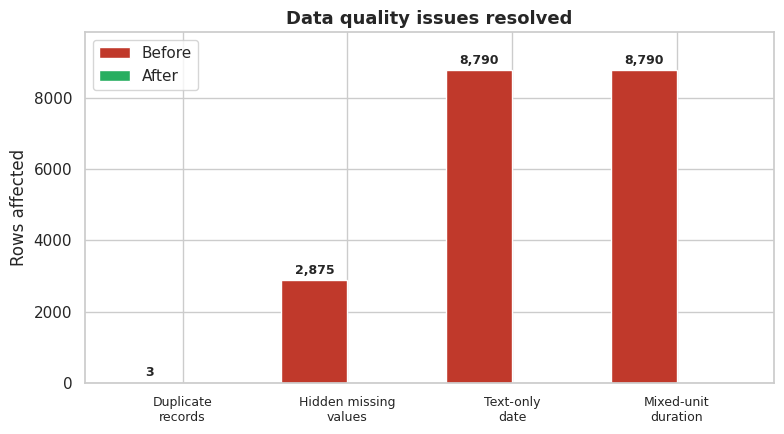

In [40]:
fig, ax = plt.subplots(figsize=(8, 4.5))

issues = ["Duplicate\nrecords", "Hidden missing\nvalues", "Text-only\ndate",
          "Mixed-unit\nduration"]
before_vals = [
    df_raw.duplicated(subset=[c for c in df_raw.columns if c != "show_id"]).sum(),
    int(df_raw[PLACEHOLDER_COLUMNS].isin(MISSING_CODES).sum().sum()),
    len(df_raw),
    len(df_raw),
]
x = np.arange(len(issues))

bars_before = ax.bar(x - 0.2, before_vals, 0.4, label="Before", color="#c0392b")
ax.bar(x + 0.2, [0] * len(issues), 0.4, label="After", color="#27ae60")

for bar, val in zip(bars_before, before_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + len(df_raw) * 0.02,
            f"{val:,}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(issues, fontsize=9)
ax.set_ylabel("Rows affected")
ax.set_title("Data quality issues resolved")
ax.set_ylim(0, len(df_raw) * 1.12)
ax.legend()

plt.tight_layout()
plt.show()

**Chart 2 — the cleaned dataset.** With `type` standardised and duplicates removed, a simple
count is now trustworthy.

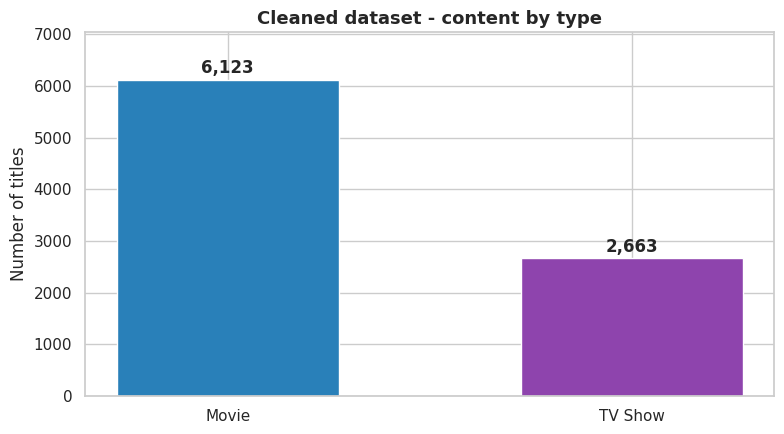

In [41]:
fig, ax = plt.subplots(figsize=(8, 4.5))

type_counts = df["type"].value_counts()

ax.bar(type_counts.index.astype(str), type_counts.values,
       color=["#2980b9", "#8e44ad"], width=0.55)

for i, v in enumerate(type_counts.values):
    ax.text(i, v + type_counts.max() * 0.02, f"{v:,}",
            ha="center", fontweight="bold")

ax.set_title("Cleaned dataset - content by type")
ax.set_ylabel("Number of titles")
ax.set_ylim(0, type_counts.max() * 1.15)

plt.tight_layout()
plt.show()

---
## 9. Export the clean dataset

Two files are written:

- `netflix_cleaned.csv` — the analysis-ready dataset, for Tasks 2 to 6
- `cleaning_report.txt` — a short log of what was changed, useful evidence for the submission

The list columns (`genres`, `countries`) are flattened back to strings on export, since CSV cannot
store a Python list. A short helper at the bottom shows how to restore them when reloading.

In [42]:
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

df_export = df.copy()
df_export["genres"] = df_export["genres"].apply(lambda lst: ", ".join(lst))
df_export["countries"] = df_export["countries"].apply(lambda lst: ", ".join(lst))

out_path = OUTPUT_DIR / "netflix_cleaned.csv"
df_export.to_csv(out_path, index=False)

print(f"Saved : {out_path}")
print(f"Shape : {df_export.shape[0]:,} rows x {df_export.shape[1]} columns")
print(f"Size  : {out_path.stat().st_size / 1024:.1f} KB")

# Excel copy as well — useful for reviewers who prefer to browse the data in a spreadsheet
try:
    xlsx_path = OUTPUT_DIR / "netflix_cleaned.xlsx"
    df_export.to_excel(xlsx_path, index=False, sheet_name="cleaned_data")
    print(f"Saved : {xlsx_path}")
except ImportError:
    print("Skipped Excel export — install openpyxl to enable it.")

Saved : output/netflix_cleaned.csv
Shape : 8,786 rows x 28 columns
Size  : 2161.7 KB


Saved : output/netflix_cleaned.xlsx


In [43]:
report = f"""
DATA CLEANING REPORT
Auspify Data Science Internship - Task 1
Intern: Wandiya James
Source file: {DATA_PATH.name}
{'=' * 62}

SHAPE
  Raw      : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns
  Cleaned  : {df.shape[0]:,} rows x {df.shape[1]} columns
  Rows removed : {len(df_raw) - len(df)} (duplicate records)
  Columns added: {df.shape[1] - df_raw.shape[1]} (derived features)

ISSUES FOUND AND RESOLVED
  1. Missing values disguised as "Not Given" in director and country.
     Converted to NaN, then filled with "Unknown" while preserving
     director_known / country_known flags. Replacement was scoped to
     these two columns so the legitimate film titled "Unknown" survived.
  2. {len(df_raw) - len(df)} duplicate records sharing identical content under
     different show_id values. Removed, keeping the first occurrence.
  3. Whitespace stripped from all text columns.
  4. date_added converted from text to datetime; year_added, month_added,
     month_name_added and years_to_platform derived from it.
  5. duration split into duration_value (numeric) and duration_unit,
     resolving the mixed minutes/seasons format. movie_minutes and
     tv_seasons added for unit-specific analysis.
  6. rating standardised: UR folded into NR, TV-Y7-FV into TV-Y7.
     audience_category derived as a broader grouping.
  7. listed_in restructured into genres (list), primary_genre and n_genres.
  8. Outliers detected with the IQR method: {int(df['runtime_outlier'].sum())} runtime outliers
     flagged. Inspection showed these to be legitimate short films and
     epics, so they were retained and flagged rather than removed.
  9. Logical consistency checked: {int(df['release_added_inconsistent'].sum())} titles appear to
     predate their own release year, caused by release_year recording the
     latest TV season rather than first airing. Flagged, not removed.
 10. Low-cardinality columns converted to category dtype
     ({(1 - df.memory_usage(deep=True).sum() / df_raw.memory_usage(deep=True).sum()) * 100:.1f}% memory reduction).

VALIDATION
  {results['passed'].sum()} of {len(results)} automated checks passed.

OUTPUT
  output/netflix_cleaned.csv
  output/netflix_cleaned.xlsx
"""

report_path = OUTPUT_DIR / "cleaning_report.txt"
report_path.write_text(report.strip())
print(report.strip())

DATA CLEANING REPORT
Auspify Data Science Internship - Task 1
Intern: Wandiya James
Source file: Dataset.csv

SHAPE
  Raw      : 8,790 rows x 10 columns
  Cleaned  : 8,786 rows x 28 columns
  Rows removed : 4 (duplicate records)
  Columns added: 18 (derived features)

ISSUES FOUND AND RESOLVED
  1. Missing values disguised as "Not Given" in director and country.
     Converted to NaN, then filled with "Unknown" while preserving
     director_known / country_known flags. Replacement was scoped to
     these two columns so the legitimate film titled "Unknown" survived.
  2. 4 duplicate records sharing identical content under
     different show_id values. Removed, keeping the first occurrence.
  3. Whitespace stripped from all text columns.
  4. date_added converted from text to datetime; year_added, month_added,
     month_name_added and years_to_platform derived from it.
  5. duration split into duration_value (numeric) and duration_unit,
     resolving the mixed minutes/seasons format

In [44]:
# How to reload the cleaned file in the next task, with list columns restored
reload_snippet = """
import pandas as pd

df = pd.read_csv("output/netflix_cleaned.csv", parse_dates=["date_added"])
df["genres"] = df["genres"].fillna("").str.split(", ")
df["countries"] = df["countries"].fillna("").str.split(", ")
"""
print("Reload snippet for Task 2 onwards:")
print(reload_snippet)

Reload snippet for Task 2 onwards:

import pandas as pd

df = pd.read_csv("output/netflix_cleaned.csv", parse_dates=["date_added"])
df["genres"] = df["genres"].fillna("").str.split(", ")
df["countries"] = df["countries"].fillna("").str.split(", ")



---
## 10. Findings and data dictionary

### What the audit turned up

1. **The dataset appeared complete but was not.** A plain `isna()` check returned zero nulls across
   every column. The real missingness — roughly 2,588 directors and 287 countries — was hidden behind
   the string `"Not Given"`. Any analysis run on the raw file would have reported `"Not Given"` as the
   most prolific director on Netflix.

2. **Missing director is systematic, not random.** It is absent for the large majority of TV shows and
   only a small fraction of movies, reflecting how Netflix catalogues series. Treating it as a random
   gap and imputing it would have been a mistake.

3. **`duration` was unusable as delivered.** Movies are measured in minutes, TV shows in seasons, both
   stored as text in the same column. Splitting the value from the unit is what makes any comparison of
   content length possible in the later tasks.

4. **A small number of records were duplicated** under different `show_id` values — identical in every
   other field, which points to a double ingestion rather than two genuinely similar titles. Three were
   visible immediately; a fourth only became detectable after whitespace was stripped, which is the
   reason cleaning order matters — deduplicating before standardising text would have missed it.

5. **One placeholder flag was a false positive.** A row with the title *Unknown* looked like missing
   data to an automated check, but is a legitimate 2011 film. Scoping the replacement to `director` and
   `country` — rather than applying it dataframe-wide — preserved it. The generic one-liner would have
   nulled a real title without raising any error.

6. **Statistical outliers were real content, not errors.** The IQR method flagged around 449 movies as
   runtime outliers. Inspecting them showed the short end to be genuine short films and the long end to
   be epics — topped by *Black Mirror: Bandersnatch* at 312 minutes, an interactive film whose runtime
   spans every branching path. Dropping them, which is the reflex the technique invites, would have
   deleted Netflix's entire short-film catalogue and skewed every runtime statistic upward. They are
   flagged instead.

7. **`release_year` means different things for movies and TV shows.** Fourteen titles appear to have
   been added to Netflix before they were released. Nearly all are TV shows off by a year or two,
   because `release_year` records the most recent season while `date_added` records first arrival. This
   is a limitation to carry into Task 4 — a forecasting model treating `release_year` as one consistent
   quantity across both content types will be subtly wrong.

8. **Ratings were fragmented.** `NR` and `UR` carry the same meaning, and `TV-Y7-FV` is a variant of
   `TV-Y7`. Left as-is, these would have split the same audience group across separate buckets.

### Data dictionary — cleaned dataset

| Column | Type | Origin | Description |
|---|---|---|---|
| `show_id` | str | original | Unique identifier for the title |
| `type` | category | original | Movie or TV Show |
| `title` | str | original | Title of the content |
| `director` | str | cleaned | Director; `"Unknown"` where not recorded |
| `country` | str | cleaned | Country of production; `"Unknown"` where not recorded |
| `date_added` | datetime | converted | Date the title was added to Netflix |
| `release_year` | int | original | Year the content was originally released |
| `rating` | category | standardised | Content rating, with `UR`/`TV-Y7-FV` folded in |
| `duration_raw` | str | renamed | Original text duration (`"90 min"`), kept for reference |
| `genres_raw` | str | renamed | Original comma-separated genre string |
| `year_added` | Int64 | derived | Year extracted from `date_added` |
| `month_added` | Int64 | derived | Month number extracted from `date_added` |
| `month_name_added` | str | derived | Month name extracted from `date_added` |
| `years_to_platform` | Int64 | derived | Years between release and being added |
| `duration_value` | Int64 | derived | Numeric part of `duration` |
| `duration_unit` | category | derived | `min` or `Season` |
| `movie_minutes` | Int64 | derived | Runtime in minutes, movies only |
| `tv_seasons` | Int64 | derived | Number of seasons, TV shows only |
| `audience_category` | category | derived | Kids / Older Kids / Teens / Adults / Unrated |
| `genres` | list | derived | Genres as a proper list |
| `primary_genre` | category | derived | First listed genre |
| `n_genres` | int | derived | Count of genres assigned |
| `countries` | list | derived | Countries as a list |
| `primary_country` | str | derived | First listed country |
| `director_known` | bool | derived | False where director was originally missing |
| `country_known` | bool | derived | False where country was originally missing |
| `runtime_outlier` | bool | derived | True for IQR-flagged runtimes (retained, not removed) |
| `release_added_inconsistent` | bool | derived | True where added to Netflix before `release_year` |

### Task 1 checklist

| Required step | Status |
|---|---|
| Step 1 — Import the dataset using Pandas | Section 2 |
| Step 2 — Identify missing and duplicate records | Section 4 |
| Step 3 — Handle null values and inconsistent formats | Sections 5.1–5.3, 5.11, 7 |
| Step 4 — Transform categorical and date-related columns | Sections 5.4–5.10 |
| Step 5 — Create a clean dataset for further analysis | Section 9 |

`output/netflix_cleaned.csv` is the input for Task 2 (Exploratory Data Analysis).